In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [8]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

In [9]:
grouped_df.head()


,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

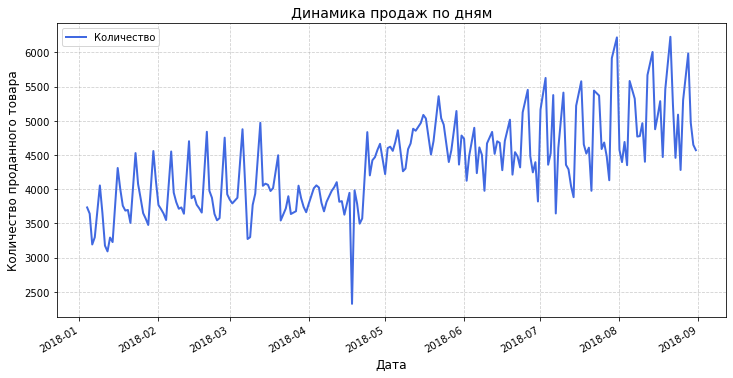

In [10]:
grouped_df.plot(x='Дата', y='Количество', figsize=(12, 6), color='royalblue', linewidth=2)
plt.title('Динамика продаж по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество проданного товара', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике отчетливо виден стабильный долгосрочный рост продаж на протяжении всего рассматриваемого периода.

Если в январе-феврале средний уровень продаж колебался в коридоре 3500–4000 единиц в день, 
то к августу-сентябрю базовый уровень продаж поднялся до 4500–5500 единиц. 
Это свидетельствует об общем увеличении масштабов бизнеса, расширении клиентской базы или росте спроса.

Глубокий провал в конце апреля (Исторический минимум): Примерно в 20-х числах апреля зафиксировано самое резкое
падение продаж за весь год — спад ниже 2500 единиц. Скорее всего, это связано с затяжными праздничными днями, 
техническим сбоем в учете или крупным недопоставлением товара на склады (Out-of-stock).

Майский скачок тренда: Сразу после апрельского падения, начиная с мая, график совершает качественный скачок 
вверх — средняя линия продаж больше не опускается ниже 4300 единиц, фиксируя выход бизнеса на новый стабильный уровень продаж.

в конце лета график достигает своего исторического максимума, пробивая отметку в 6200 проданных единиц за сутки.

График наглядно доказывает, что компании необходимо увеличивать складские запасы к началу августа. 
Спрос в конце лета лавинообразно растет, и если склад не будет готов к июльско-августовскому пику, бизнес столкнется с 
дефицитом и упустит максимальную прибыль года. 
К осенне-зимнему периоду (сентябрь) график начинает плавное снижение, формируя локальный спад. 
    

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
max_outlier_row = df.loc[df['Количество'].idxmax()]
max_outlier_row

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [12]:
# Условия: 3-й склад, месяцы июнь(6), июль(7), август(8) и день недели — среда (2)
summer_wednesdays_warehouse3 = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

# Группируем отфильтрованные данные по товарам (Номенклатура) и суммируем продажи
product_sales = summer_wednesdays_warehouse3.groupby('Номенклатура')['Количество'].sum().reset_index()

# Находим строку с максимальным суммарным количеством продаж
top_product_row = product_sales.loc[product_sales['Количество'].idxmax()]

# Выводим итоговый топовый товар на экран
print("Абсолютный лидер продаж по средам за лето на 3-м складе:")
top_product_row


Абсолютный лидер продаж по средам за лето на 3-м складе:


Номенклатура    product_1
Количество           2267
Name: 1, dtype: object

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [14]:
# Извлекаем все уникальные годы из столбца 'Дата'
unique_years = df['Дата'].dt.year.unique()
print(unique_years)

# Выводим самую раннюю и самую позднюю даты в таблице
min_date = df['Дата'].min()
max_date = df['Дата'].max()
print(f"Период данных: с {min_date.strftime('%d.%m.%Y')} по {max_date.strftime('%d.%m.%Y')}")


[2018]
Период данных: с 04.01.2018 по 31.08.2018


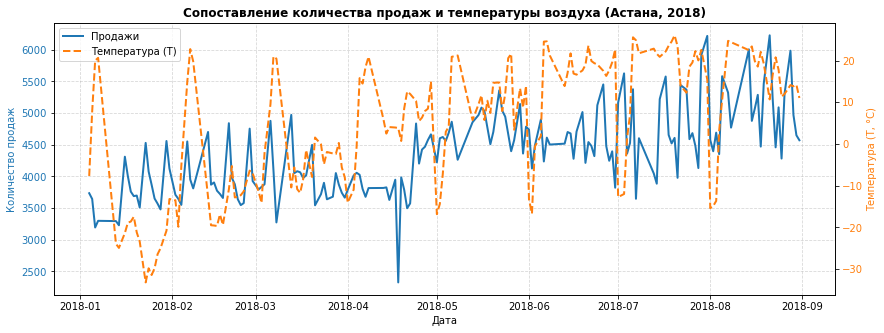

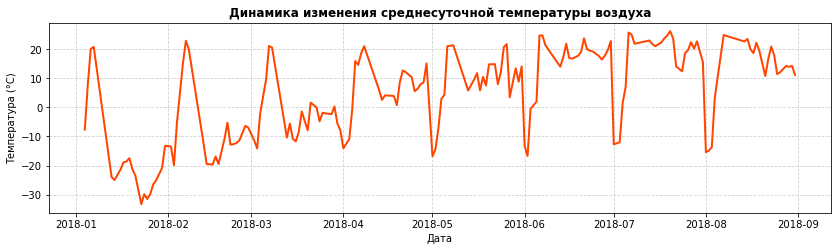

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Чтение и подготовка данных о погоде
weather_df = pd.read_excel('weather.xls', skiprows=6)
weather_df.columns = weather_df.columns.str.strip() 
weather_df = weather_df.rename(columns={weather_df.columns[0]: 'Full_Date', 'T': 'T'})

# Выделяем дату без времени и считаем среднюю температуру за день
weather_df['Дата'] = pd.to_datetime(weather_df['Full_Date'], errors='coerce').dt.normalize()
daily_weather = weather_df.groupby('Дата')['T'].mean().reset_index()

# Синхронизация дат и объединение таблиц
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()
merged_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

# Построение совмещенного графика (Продажи + Температура)
fig, ax1 = plt.subplots(figsize=(14, 5))

# Левая ось: Продажи
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='tab:blue')
line1 = ax1.plot(merged_df['Дата'], merged_df['Количество'], color='tab:blue', linewidth=2, label='Продажи')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# Правая ось: Температура T
ax2 = ax1.twinx()  
ax2.set_ylabel('Температура (T, °C)', color='tab:orange')
line2 = ax2.plot(merged_df['Дата'], merged_df['T'], color='tab:orange', linewidth=2, linestyle='--', label='Температура (T)')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Объединяем легенду
lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
plt.title('Сопоставление количества продаж и температуры воздуха (Астана, 2018)', fontweight='bold')
plt.show()

# 4. Построение отдельного графика температуры
plt.figure(figsize=(14, 3.5))
plt.plot(merged_df['Дата'], merged_df['T'], color='orangered', linewidth=2)
plt.title('Динамика изменения среднесуточной температуры воздуха', fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
